# DL065 设备显存与性能测量

真实按序执行，包含完整重训、可复核输出与内嵌图。所有新输出写入notebook_outputs。

In [1]:
from pathlib import Path
import sys, json, copy, numpy as np, torch
import experiment as e
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
def show(fig):
    b=BytesIO(); fig.savefig(b,format='png',dpi=135,bbox_inches='tight')
    display(Image(data=b.getvalue())); plt.close(fig)
torch.set_num_threads(1)
print({'python':sys.version.split()[0],'torch':torch.__version__,'unit':Path.cwd().name,'device':'CPU'})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'unit': '065', 'device': 'CPU'}


## 1 参数与状态账本

先数元素再数bytes。账本不是峰值内存。

In [2]:
m=e.make_model();o=torch.optim.Adam(m.parameters(),foreach=False)
print('before',e.memory_ledger(m,o))
e.step(m,o,*e.make_data(8))
print('after',e.memory_ledger(m,o))

before {'parameter_bytes': 83976, 'gradient_bytes': 0, 'optimizer_tensor_bytes': 0, 'logical_total_bytes': 83976, 'scope': 'tensor element payload only; excludes activations, allocator, workspaces and Python overhead'}
after {'parameter_bytes': 83976, 'gradient_bytes': 83976, 'optimizer_tensor_bytes': 167976, 'logical_total_bytes': 335928, 'scope': 'tensor element payload only; excludes activations, allocator, workspaces and Python overhead'}


## 2 正确性测试

测试相同目标、梯度与更新，不设置速度阈值。

In [3]:
import unittest, test_experiment
result=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not result.wasSuccessful(): raise RuntimeError('unit tests failed')

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 11 tests in 0.036s

OK


## 3 完整实际训练与基准

重新完成320次训练更新、独立计时与profiler，写入新目录。计时会变。

In [4]:
r=e.main(Path('notebook_outputs'))
print('final:',r['history'][-1])
for z in r['measurements']: print(z['implementation'],z['median_seconds'],z['samples_per_second'])
print('GPU memory:',r['gpu_memory'])

final: {'epoch': 20, 'train_loss': 0.0008160175057128072, 'test_accuracy': 0.92578125}
vectorized 0.0005048333000559069 126774.52139728586
row_loop 0.0062191256000005525 10290.835740637609
GPU memory: None


## 4 实测学习曲线

测试集独立生成；单次种子不是现实性能保证。

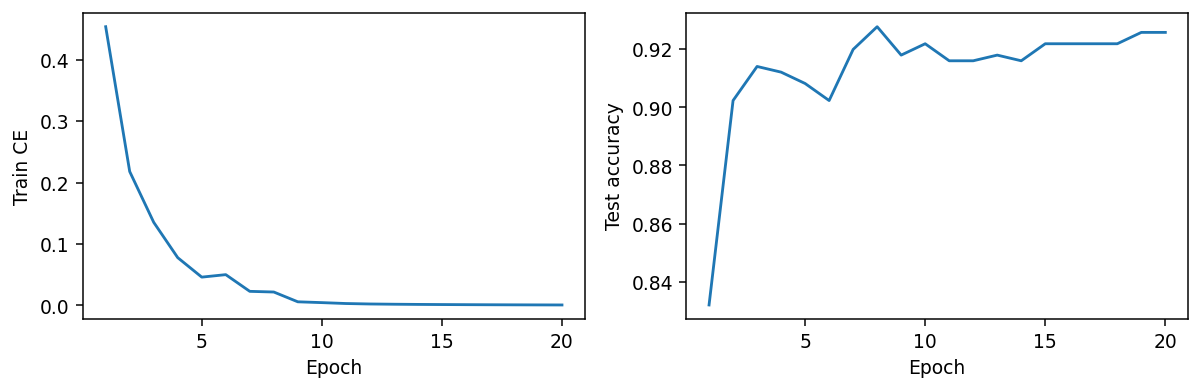

In [5]:
fig,axes=plt.subplots(1,2,figsize=(9,3))
h=r['history']
axes[0].plot([z['epoch'] for z in h],[z['train_loss'] for z in h]);axes[0].set(xlabel='Epoch',ylabel='Train CE')
axes[1].plot([z['epoch'] for z in h],[z['test_accuracy'] for z in h]);axes[1].set(xlabel='Epoch',ylabel='Test accuracy');fig.tight_layout();show(fig)

## 5 稳态块而非最小一次

图显示实际多个计时块；没有计入I/O或传输。

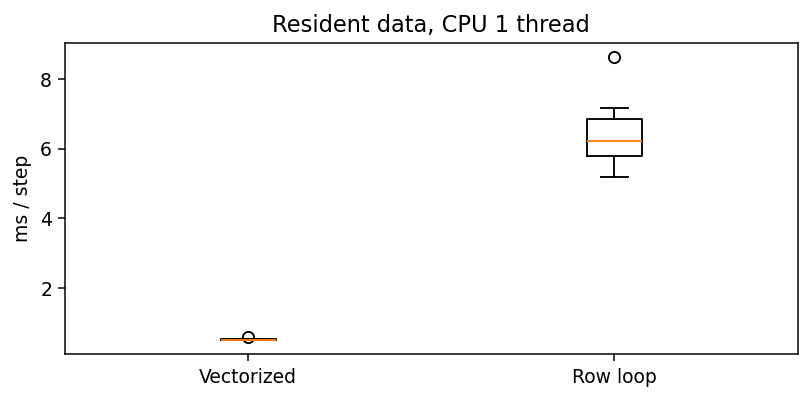

In [6]:
fig,ax=plt.subplots(figsize=(7,3))
ax.boxplot([[v*1000 for v in z['seconds_per_step_blocks']] for z in r['measurements']],tick_labels=['Vectorized','Row loop'])
ax.set(ylabel='ms / step',title='Resident data, CPU 1 thread');show(fig)

## 6 checkpoint复核

只加载可信文件，恢复真实训练权重并核对终点。

In [7]:
saved=torch.load('notebook_outputs/trained_model.pt',weights_only=True)
m=e.make_model();m.load_state_dict(saved['state_dict']);a=np.load('notebook_outputs/data.npz')
with torch.no_grad(): score=float((m(torch.from_numpy(a['test_x'])).argmax(1)==torch.from_numpy(a['test_y'])).float().mean())
print('reload accuracy',score)
if abs(score-r['history'][-1]['test_accuracy'])>1e-8: raise RuntimeError('checkpoint mismatch')

reload accuracy 0.92578125


## 7 分析器的边界

self time不是父子total时间之和，事件内存不是峰值。

In [8]:
print(r['profile'][:5])
print('memory scope:',r['memory_after_training']['scope'])

[{'operator': 'Optimizer.step#Adam.step', 'calls': 5, 'self_cpu_us': 1051.204999999999, 'cpu_total_us': 2380.654, 'self_cpu_memory_bytes': -839760}, {'operator': 'aten::mm', 'calls': 25, 'self_cpu_us': 969.6980000000003, 'cpu_total_us': 976.2980000000013, 'self_cpu_memory_bytes': 1070080}, {'operator': 'course_backward', 'calls': 5, 'self_cpu_us': 726.7229999999967, 'cpu_total_us': 2695.05, 'self_cpu_memory_bytes': -20}, {'operator': 'aten::addmm', 'calls': 15, 'self_cpu_us': 555.6499999999957, 'cpu_total_us': 636.9849999999994, 'self_cpu_memory_bytes': 660480}, {'operator': 'course_forward', 'calls': 5, 'self_cpu_us': 290.16099999999835, 'cpu_total_us': 1285.177, 'self_cpu_memory_bytes': -655360}]
memory scope: tensor element payload only; excludes activations, allocator, workspaces and Python overhead
